<div align="right">
  <font color="#00796B" size="4"><b>
  TEAM 우리터빈이달라졌어요
  </b></font>
</div>

# 풍력 발전기 스마트 예방 정비 시스템 구축

이 노트북은 풍력 발전기 표면 이미지 데이터셋을 사용하여 Object Detection 모델을 실제로 학습하고 평가하는 최종 제출용 노트북이다.   

### 팀정보
- 팀명 : 우리터빈이달라졌어요
- 팀 구성원:
  - 조현겸(팀장) : 통합 QA 및 산출물 총괄
  - 서한호 : 실험 설계 담당
  - 이다겸 : 문제 및 데이터 담당
  - 임성배 : MVP/결론 담당
  - 천세문 : 최종 모델/검증 담당

---
### 상세 역할 분담

<div align="center">

| 성함 | 역할 | 주요 수행 내용 |
| :--- | :--- | :--- |
| **조현겸** | 통합 QA 및 산출물 총괄 | • 주피터 노트북 루브릭 점검 및 전체 코드 통합<br>• 발표 자료(PPT) 취합 및 디자인 통일<br>• 자체 리허설 총괄(타임키퍼) |
| **이다겸** | 문제 및 데이터 담당 | • 테스트 데이터 바운딩 박스 시각화 협업<br>• 발표 자료 작성 (배경 및 EDA 파트) |
| **서한호** | 실험 설계 담당 | • 성능 개선 수치적 근거(Metric 추이) 정리<br>• 노트북 내 모델 실험 코드 정제<br>• 발표 자료 작성 (모델 실험 과정 파트) |
| **천세문** | 최종 모델/검증 담당 | • 최종 분석 및 최고 성능 모델 확정<br>• 노트북 내 검증/결과 코드 정제<br>• 발표 자료 작성 (최종 모델 선정 근거 및 검증 결과) |
| **임성배** | MVP/결론 담당 | • 결론 도출 및 기대효과 정리<br>• 최종 모델 데모 웹 탑재 및 시연 시나리오 완성<br>• LMS 최종 제출 및 본 발표 진행 |

</div>

### 제출일
- 2026년 7월 3일


# 최종 모델 평가 — YOLO11m·640 (base)

> 5개 후보(base·box·img768·배경HN·best) 중 <b>base(11m·640·100ep)</b>를 최종 모델로 선정.

<br>
<br>

## 최종 실험 전략  
복잡한 선택지를 줄이고 다음 흐름으로 고정한다.
  + 전제 — 분할부터 고정. 모든 실험을 동일한 결정적 시퀀스 분할 위에서 돌린다. (누가 어디서 돌려도 같은 val이 나오도록)
  + Stage 1 — 체급×해상도 스크리닝. 후보 5종(A 11s·640 / B 11s·960 / C 11m·640 / D 11m·960 / E 11l·640)을 <b>동일 조건(100ep·조기종료)</b>으로 학습하고, 동일 val 분할에서 비교한다.
  + Stage 2 — 실패 방향 제외. 960 해상도 라인(B·D)은 전체 mAP50-95를 오히려 떨어뜨려 최종 후보에서 제외한다. Dirt 오버샘플(OS3)도 타겟과 방향이 안 맞아 폐기한다.
  + Stage 3 — 상위 체급에서 개선 프리셋 검증. 최고 체급인 11m·640을 기준으로 개선 프리셋(base / box / img768 / 배경 하드네거티브 / best)을 검증한다.
  + Stage 4 — val로 최종 확정. 최종 모델은 val 결과표에서 선택한다 → YOLO11m·640 base.
  + 로그는 실험당 한 줄만. epoch별 로그는 전부 출력하지 않고, 실험이 끝날 때마다 트래커용 한 줄만 출력한다.
  + 최종적으로 결과표, 요인 분석 그래프, 예측 시각화, 실패(놓침/오탐) 사례, IoU별 Damage AP, confusion matrix, checkpoint 저장까지 수행한다.

<br>

## 핵심 수정 사항
베이스라인 모델에서 데이터 분할·평가 방식을 수정하였다.
  + 프레임 누수 제거. 같은 촬영 연속 프레임(동일 DJI_####)이 train/val에 걸치지 않도록 시퀀스 단위 분할을 적용
  + Dirt 오버샘플 제거. 소수 클래스(Dirt) 복제는 다수 클래스인 Damage에 오히려 불리 → 폐기.
  + 평가 지표 분리. 전체 `mAP50-95`만 보면 Damage 성능을 놓친다 → Damage 클래스별 `AP·Recall`을 따로 집계하고, 비교는 동일 val 분할에서만 수행.

<br>

## 최종 수정 포인트
이 완성본에서는 다음 심사 리스크를 제거했다.
  + **실패 실험 승격 차단** — 960 해상도·Dirt 오버샘플이 최종 후보로 올라가지 않도록 제외.
  + **test 부재 해소** — 시퀀스 단위 3분할(train/val/test) 도입, test는 최종 1회만 사용(선택엔 val만).
  + <b>최종 checkpoint(best.pt) 저장</b> + 세션 끊김 대비 resume/save_period.
  + <b>confusion matrix·IoU별 Damage AP 해석 추가</b> — 낮은 mAP50-95의 원인을 오탐(FP) vs 위치 정확도(localization)로 규명.

# 0. GPU 확인

In [ ]:
!nvidia-smi
import torch; print('CUDA:', torch.cuda.is_available())

Thu Jul  2 05:19:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1. 환경 설치

In [ ]:
# 라이브러리 로드 이전에 반드시 수행
%pip install -q -U ultralytics
import ultralytics; print(ultralytics.__version__); ultralytics.checks()

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 46.7/112.6 GB disk)


### 1-1. 라이브러리 로드

In [ ]:
# 1. 파이썬 내장 라이브러리 (기본 파일 시스템 및 데이터 처리)
import os                       # 파일 경로 설정 및 디렉터리 생성/제어
import re                       # 정규표현식을 이용한 시퀀스 키(DJI_*) 추출
import random                   # 데이터 셔플 및 무작위성 제어를 위한 시드(Seed) 설정
import shutil                   # 파일 복사(copy2) 및 폴더 삭제(rmtree)
import yaml                     # data.yaml 설정 파일 읽기 및 쓰기
from collections import defaultdict, Counter  # 시퀀스 그룹화 및 클래스 인스턴스 개수 카운트

# 2. 데이터 분석 및 모델 학습 관련 핵심 라이브러리
import torch                    # PyTorch 및 CUDA(GPU) 장치 확인용
from ultralytics import YOLO    # YOLOv11 모델 로드, 학습(train) 및 평가(val)

# 3. Google Colab 전용 및 편의성 라이브러리
from google.colab import drive  # 구글 드라이브 마운트용

# tqdm 설치 여부에 따른 방어 코드 (진행 상황 바 시각화)
try:
    from tqdm.auto import tqdm
except ImportError:
    # tqdm이 없을 경우 에러 방지를 위한 더미(Dummy) 함수 대체
    def tqdm(x, **kwargs): return x

### 1-2. 실행 설정

In [ ]:
# ==============================================================================
# 1. 데이터 분할 및 전처리 설정 (Data Split Settings)
# ==============================================================================
VAL_RATIO      = 0.15   # 검증(Validation) 데이터 비율
TEST_RATIO     = 0.15   # 최종 평가(Test) 데이터 비율 (나머지 0.70은 Train)
NUM_BACKGROUND = 600    # 모델의 오탐률을 줄이기 위해 Train 세트에만 추가할 배경(정상) 이미지 수
OUT  = '/content/yolo_dataset_3way'   # 로컬(쓰기 가능·빠름)
SEED     = 42           # 데이터 셔플 및 모델 학습용 고정 시드값 (결정적 결과 보장)
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')  # 허용할 이미지 확장자 목록


# ==============================================================================
# 2. 모델 하이퍼파라미터 설정 (YOLO Hyperparameters)
# ==============================================================================
MODEL    = 'yolo11m.pt'                 # 사용할 YOLOv11 Base 가중치 모델
IMGSZ    = 640                          # 입력 이미지 리사이즈 크기
EPOCHS   = 100                          # 최대 학습 에포크 수
PATIENCE = 20                           # Early Stopping(조기 종료) 대기 에포크 수
BATCH    = 16                           # 배치 크기 (OOM 발생 시 8 또는 4로 하향 조정)

EXP_NAME = 'final_11m_640_base_3way'    # 이번 최종 실험의 고유 이름 (Run 폴더명)

# 2. Google Drive 마운트

In [ ]:
drive.mount('/content/drive')
DRIVE_ROOT = '/content/drive/MyDrive/wind_turbine_yolo'
RUNS_DIR = os.path.join(DRIVE_ROOT, 'runs')
os.makedirs(RUNS_DIR, exist_ok=True)
print('runs:', RUNS_DIR)

runs: /content/drive/MyDrive/wind_turbine_yolo/runs


# 3. 원본 데이터 경로
images/·labels/ 폴더가 있는 **원본** 데이터 루트를 지정. (공유 폴더가 읽기전용이어도, 결과는 로컬 `/content`에 쓰므로 OK)

In [ ]:
DATA_ROOT = '/content/drive/MyDrive/data/raw/NordTank586x371'
def locate(root):
    img=lab=None
    for r,_,_ in os.walk(root):
        b=os.path.basename(r).lower()
        if b=='images' and img is None: img=r
        if b=='labels' and lab is None: lab=r
    return img,lab
IMAGES_DIR, LABELS_DIR = locate(DATA_ROOT)
print('IMAGES_DIR =', IMAGES_DIR); print('LABELS_DIR =', LABELS_DIR)
assert IMAGES_DIR and LABELS_DIR, '원본에서 images/labels 못 찾음 → DATA_ROOT 확인'


IMAGES_DIR = /content/drive/MyDrive/data/raw/NordTank586x371/images
LABELS_DIR = /content/drive/MyDrive/data/raw/NordTank586x371/labels


In [ ]:
# 이미지와 라벨 경로 및 파일 확인

# 이미지 파일 개수 세기 (하위 폴더 포함)
img_count = sum(
    1 for r, _, fs in os.walk(IMAGES_DIR)
    for fn in fs if os.path.splitext(fn)[1].lower() in IMG_EXTS
)

# 라벨 파일 개수 세기 (.txt 확장자만, 하위 폴더 포함)
label_count = sum(
    1 for r, _, fs in os.walk(LABELS_DIR)
    for fn in fs if os.path.splitext(fn)[1].lower() == '.txt'
)

print("-" * 30)
print(f"📷 원본 이미지 개수: {img_count:,}개")
print(f"📄 원본 라벨(.txt) 개수: {label_count:,}개")
print("-" * 30)

------------------------------
📷 원본 이미지 개수: 13,470개
📄 원본 라벨(.txt) 개수: 2,996개
------------------------------


# 4. EDA

EDA 내용은 별도의 EDA 수행 노트북을 참고한다. <br>
`Wind_turbine_Detection_EDA.ipynb`



# 5. 3분할 생성 (train 70 / val 15 / test 15 · 시퀀스 단위)

실행 후 `/content/yolo_dataset_3way/data.yaml` 생성. 로컬(`/content`)이라 캐시 쓰기 권한 문제 없음.

In [ ]:
def label_for(im): return os.path.join(LABELS_DIR, os.path.splitext(os.path.basename(im))[0]+'.txt')
def seq_key(p):
    m=re.match(r'(DJI_\d+)', os.path.basename(p))
    return m.group(1) if m else os.path.basename(p).split('_')[0]
def has_label(lp): return os.path.exists(lp) and os.path.getsize(lp)>0

# 이미지 정렬(파일순서 의존 제거) → 라벨/배경 분류
print('스캔 중...', flush=True)
images = sorted(os.path.join(r,fn) for r,_,fs in os.walk(IMAGES_DIR)
                for fn in fs if os.path.splitext(fn)[1].lower() in IMG_EXTS)
labeled=[im for im in images if has_label(label_for(im))]
background=[im for im in images if not has_label(label_for(im))]
print(f'라벨 {len(labeled)} | 배경 {len(background)}', flush=True)

# 시퀀스 그룹 → 결정적 셔플 → test, val, train 순 배정
groups=defaultdict(list)
for im in labeled: groups[seq_key(im)].append(im)
gk=sorted(groups.keys()); random.seed(SEED); random.shuffle(gk)
n=len(labeled); test_g=set(); val_g=set(); tc=vc=0
for g in gk:
    if tc < n*TEST_RATIO: test_g.add(g); tc+=len(groups[g])
    elif vc < n*VAL_RATIO: val_g.add(g); vc+=len(groups[g])
train_imgs=[i for g in gk if g not in test_g and g not in val_g for i in groups[g]]
val_imgs  =[i for g in val_g  for i in groups[g]]
test_imgs =[i for g in test_g for i in groups[g]]
bg_pool=sorted(p for p in background if seq_key(p) not in val_g and seq_key(p) not in test_g)
random.seed(SEED); random.shuffle(bg_pool); train_bg=bg_pool[:NUM_BACKGROUND]
print(f'시퀀스 {len(gk)} → train {len(train_imgs)}(+배경 {len(train_bg)}) / val {len(val_imgs)} / test {len(test_imgs)}', flush=True)

# 재실행 안전: 기존 OUT 삭제 후 재생성
if os.path.exists(OUT): shutil.rmtree(OUT, ignore_errors=True)
for s in ('train','val','test'):
    os.makedirs(f'{OUT}/images/{s}', exist_ok=True); os.makedirs(f'{OUT}/labels/{s}', exist_ok=True)

def place(im, s):
    stem=os.path.splitext(os.path.basename(im))[0]
    shutil.copy(im, f'{OUT}/images/{s}/{stem}{os.path.splitext(im)[1]}')
    lp=label_for(im); dst=f'{OUT}/labels/{s}/{stem}.txt'
    if os.path.exists(lp): shutil.copy(lp, dst)
    else: open(dst,'w').close()

print('복사 중 (드라이브면 몇 분)...', flush=True)
for im in tqdm(train_imgs, desc='train'): place(im,'train')
for im in tqdm(train_bg,  desc='train-bg'): place(im,'train')
for im in tqdm(val_imgs,  desc='val'):  place(im,'val')
for im in tqdm(test_imgs, desc='test'): place(im,'test')

# data.yaml (클래스 순서 그대로)
with open(f'{OUT}/data.yaml','w') as f:
    f.write(f'path: {OUT}\ntrain: images/train\nval: images/val\ntest: images/test\nnc: 2\nnames:\n  0: Dirt\n  1: Damage\n')
print('✅ data.yaml 작성:', f'{OUT}/data.yaml', flush=True)


스캔 중...
라벨 2995 | 배경 10475
시퀀스 510 → train 2086(+배경 600) / val 455 / test 454
복사 중 (드라이브면 몇 분)...


train:   0%|          | 0/2086 [00:00<?, ?it/s]

train-bg:   0%|          | 0/600 [00:00<?, ?it/s]

val:   0%|          | 0/455 [00:00<?, ?it/s]

test:   0%|          | 0/454 [00:00<?, ?it/s]

✅ data.yaml 작성: /content/yolo_dataset_3way/data.yaml


In [ ]:
# 세션 종료로 인해서 분할 내역이 사라지는 것을 방지하기 위해서 실행

# 1. 원본 경로 및 드라이브 저장 경로 설정
SOURCE_DIR = '/content/yolo_dataset_3way'
# 구글 드라이브 내에 저장하고 싶은 경로 지정 (원하는 이름으로 수정 가능)
DRIVE_OUT = '/content/drive/MyDrive/data/processed/yolo_dataset_3way'

print("🔄 Google Drive로 데이터셋 백업을 시작합니다...")

# 2. 만약 드라이브에 기존 폴더가 있다면 안전하게 덮어쓰기 위해 삭제 후 생성
if os.path.exists(DRIVE_OUT):
    print(f"⚠️ 이미 드라이브에 {DRIVE_OUT} 경로가 존재하여 기존 데이터를 삭제합니다.")
    shutil.rmtree(DRIVE_OUT)

os.makedirs(DRIVE_OUT, exist_ok=True)

# 3. tqdm을 활용하여 파일들을 하나씩 복사 (진행 상황 시각화)
# 소스 폴더 내의 모든 파일/폴더 구조를 스캔합니다.
files_to_copy = []
for root, dirs, files in os.walk(SOURCE_DIR):
    for file in files:
        src_file_path = os.path.join(root, file)
        # 소스 경로를 드라이브 경로로 변경
        rel_path = os.path.relpath(src_file_path, SOURCE_DIR)
        dst_file_path = os.path.join(DRIVE_OUT, rel_path)
        files_to_copy.append((src_file_path, dst_file_path))

print(f"📦 총 {len(files_to_copy):,}개의 파일을 복사합니다. (드라이브 속도에 따라 수 분 소요)")

for src, dst in tqdm(files_to_copy, desc="구글 드라이브 복사 중"):
    # 목적지 폴더가 없으면 생성
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(src, dst)

print(f"\n✅ 백업 완료! 구글 드라이브에서 확인하세요:\n➡️ {DRIVE_OUT}")

🔄 Google Drive로 데이터셋 백업을 시작합니다...
⚠️ 이미 드라이브에 /content/drive/MyDrive/data/processed/yolo_dataset_3way 경로가 존재하여 기존 데이터를 삭제합니다.
📦 총 7,191개의 파일을 복사합니다. (드라이브 속도에 따라 수 분 소요)


구글 드라이브 복사 중:   0%|          | 0/7191 [00:00<?, ?it/s]


✅ 백업 완료! 구글 드라이브에서 확인하세요:
➡️ /content/drive/MyDrive/data/processed/yolo_dataset_3way


### (선택) 세션 다시 시작 후 로컬로 복사 할 경우에만 실행

In [ ]:

# 1. 드라이브의 데이터셋 경로와 로컬 복사 목적지 경로
DRIVE_OUT = '/content/drive/MyDrive/data/processed/yolo_dataset_3way'
OUT = '/content/yolo_dataset_3way'

# 2. 로컬에 기존 데이터가 남아있다면 안전하게 초기화 후 복사
if os.path.exists(OUT):
    shutil.rmtree(OUT)

print("🔄 구글 드라이브에서 로컬(/content)로 데이터셋 복사 중...")
# 시스템 명령어로 고속 복사
!cp -r "{DRIVE_OUT}" "{OUT}"
print("✅ 복사 완료! 이제 아래 셀의 학습 재개 코드를 실행하세요.")

🔄 구글 드라이브에서 로컬(/content)로 데이터셋 복사 중...
✅ 복사 완료! 이제 아래 셀의 학습 재개 코드를 실행하세요.


# 6. 분할 검증

각 split의 이미지 수와 클래스 인스턴스 수 확인

In [ ]:
DATA_YAML=f'{OUT}/data.yaml'
# split 검증
def sig(sp):
    d=f'{OUT}/labels/{sp}'; cnt=Counter()
    for fn in os.listdir(d):
        p=os.path.join(d,fn)
        if os.path.getsize(p)>0:
            for ln in open(p):
                q=ln.split()
                if len(q)>=5: cnt[int(float(q[0]))]+=1
    return len(os.listdir(f'{OUT}/images/{sp}')), sum(cnt.values()), cnt[0], cnt[1]
for sp in ('train','val','test'):
    im,inst,dt,dm=sig(sp); print(f'{sp:5} | img {im:5} | inst {inst:5} (Dirt {dt} / Damage {dm})')
import yaml
NAMES=yaml.safe_load(open(DATA_YAML))['names']
DAMAGE_ID=[int(k) for k,v in (NAMES.items() if isinstance(NAMES,dict) else enumerate(NAMES)) if str(v).lower()=='damage'][0]
print('✅ DATA_YAML =', DATA_YAML, '| DAMAGE_ID =', DAMAGE_ID)

train | img  2686 | inst  6625 (Dirt 417 / Damage 6208)
val   | img   455 | inst  1345 (Dirt 83 / Damage 1262)
test  | img   454 | inst  1381 (Dirt 81 / Damage 1300)
✅ DATA_YAML = /content/yolo_dataset_3way/data.yaml | DAMAGE_ID = 1


# 7. 최종 모델 설정 — 11m · 640 · base

In [ ]:
MODEL='yolo11m.pt'
IMGSZ=640; EPOCHS=100; PATIENCE=20; BATCH=16   # OOM 시 BATCH 8→4
EXP_NAME='final_11m_640_base_3way'             # 최종 모델 run 폴더
print('최종 모델:', EXP_NAME, '| imgsz', IMGSZ, '| epochs', EPOCHS)

최종 모델: final_11m_640_base_3way | imgsz 640 | epochs 100


# 8. 학습 (train으로 학습 · val로 조기종료/최고 epoch 선택)

`resume` 지원 + `save_period=10`(끊김 대비). test는 학습에 전혀 안 쓰임.

In [ ]:
from ultralytics import YOLO
import os
last=os.path.join(RUNS_DIR,'detect',EXP_NAME,'weights','last.pt')
if os.path.exists(last):
    print('이어서 학습:', last); model=YOLO(last); results=model.train(resume=True)
else:
    print('새 학습:', MODEL); model=YOLO(MODEL)
    results=model.train(
        data=DATA_YAML, imgsz=IMGSZ, epochs=EPOCHS, batch=BATCH, patience=PATIENCE,
        project=os.path.join(RUNS_DIR,'detect'), name=EXP_NAME,
        seed=42, exist_ok=True, save_period=10,
    )

새 학습: yolo11m.pt
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_3way/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_11m_640_base_3way, nbs=64, nms=False, opset=None, optimize=False, 

## 8-1. 🔄 세션 끊김 시 재시작
끊기면 **[1.설치]→[2.마운트]→[4.3분할 생성]** 실행 후 아래 셀 실행. (`/content`는 세션마다 초기화되므로 3분할도 다시 생성)

In [ ]:
import os
from ultralytics import YOLO
RUNS_DIR=os.path.join(globals().get('DRIVE_ROOT','/content/drive/MyDrive/wind_turbine_yolo'),'runs')
EXP_NAME=globals().get('EXP_NAME','final_11m_640_base_3way')
last=os.path.join(RUNS_DIR,'detect',EXP_NAME,'weights','last.pt')
assert os.path.exists(last), f'체크포인트 없음: {last}'
model=YOLO(last); results=model.train(resume=True); print('✅ 재개 완료')


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_3way/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/wind_turbine_yolo/runs/detect/final_11m_640_base_3way/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_1

# 9. val 평가 (참고 — 선택 근거)

학습 중 조기종료 기준. test와 비교해 과적합 정도 참고.

In [ ]:
m=model.val(data=DATA_YAML, split='val', imgsz=IMGSZ, iou=0.6)
print('[VAL] mAP50', round(m.box.map50,4), '| mAP50-95', round(m.box.map,4))
vi=[int(i) for i in m.box.ap_class_index]
for c in vi: print(f'  [{m.names[c]:6}] AP50-95={m.box.maps[c]:.4f}  Recall={float(m.box.r[vi.index(c)]):.4f}')

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11m summary (fused): 126 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3072.8±720.7 MB/s, size: 214.9 KB)
val: Scanning /content/yolo_dataset_3way/labels/val.cache... 455 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 455/455 136.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 5.3it/s 5.4s
                   all        455       1345       0.87      0.728      0.804      0.553
                  Dirt         79         83      0.924      0.819      0.859      0.683
                Damage        393       1262      0.816      0.636      0.749      0.423
Speed: 0.7ms preprocess, 7.0ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
[VAL] mAP50 0.8041 | mAP50-95 0.5528
  [Dirt  ] AP50-95=0.6827  Recall=0.8193
  [Damage

# 10. 🏁 최종 test 평가
**이 노트북의 결과물.** test는 학습·선택에 안 쓰였으므로 비편향 최종 성능이다.

In [ ]:
from ultralytics import YOLO
import os
best_pt=os.path.join(RUNS_DIR,'detect',EXP_NAME,'weights','best.pt')
assert os.path.exists(best_pt), f'best.pt 없음: {best_pt}'
mt=YOLO(best_pt).val(data=DATA_YAML, split='test', imgsz=IMGSZ, iou=0.6,
                     project=os.path.join(RUNS_DIR,'detect'), name=EXP_NAME+'_TEST', exist_ok=True)
print('===== TEST (최종·비편향 성능) =====')
print('mAP50    :', round(mt.box.map50,4))
print('mAP50-95 :', round(mt.box.map,4))
print('Precision:', round(mt.box.mp,4), '| Recall:', round(mt.box.mr,4))
ti=[int(i) for i in mt.box.ap_class_index]
for c in ti:
    print(f'  [{mt.names[c]:6}] AP50-95={mt.box.maps[c]:.4f}  Recall={float(mt.box.r[ti.index(c)]):.4f}')
# IoU별 Damage AP
import numpy as np
pos=ti.index(DAMAGE_ID); dmg_ap=np.asarray(mt.box.all_ap[pos]).ravel()
apf=lambda t: float(dmg_ap[int(round((t-0.5)/0.05))])
print(f'\nDamage AP@0.50={apf(0.5):.4f} | @0.75={apf(0.75):.4f} | @0.90={apf(0.9):.4f}')
print(f'\n[최종 보고 한 줄] final 11m·640 base | TEST mAP50 {round(mt.box.map50,3)} | mAP50-95 {round(mt.box.map,3)} '
      f'| Damage AP50-95 {round(float(mt.box.maps[DAMAGE_ID]),3)} | Damage R {round(float(mt.box.r[ti.index(DAMAGE_ID)]),3)}')


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11m summary (fused): 126 layers, 20,031,574 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2337.6±1004.4 MB/s, size: 268.2 KB)
val: Scanning /content/yolo_dataset_3way/labels/test... 454 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 454/454 1.3Kit/s 0.3s
val: New cache created: /content/yolo_dataset_3way/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 5.2it/s 5.6s
                   all        454       1381      0.817      0.752      0.786      0.545
                  Dirt         77         81      0.858      0.818      0.836      0.679
                Damage        393       1300      0.777      0.685      0.736       0.41
Speed: 0.7ms preprocess, 6.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/drive/MyDrive/wind_turbine_yolo/runs/det

Validation 데이터셋을 활용한 추론 결과와 Test 데이터셋을 통한 최종 평가 결과를 비교 분석하였다. <br><br>
**Validation 및 Test 데이터셋 성능 비교**
- Validation: mAP50=0.8041, mAP50-95=0.5528
  - [Dirt] AP50-95=0.6827, Recall=0.8193
  - [Damage] AP50-95=0.4228, Recall=0.6363
- Test: mAP50=0.7859, mAP50-95=0.5447 (Precision=0.8172, Recall=0.7518)
  - [Dirt] AP50-95=0.6790, Recall=0.8183
  - [Damage] AP50-95=0.4104, Recall=0.6854

수치상으로 모델은 Test 데이터셋에서도 Validation과 유사한 성능을 도출해 내며 안정적인 일반화 성능을 보였다. 특히 Damage 클래스의 경우, 검출률을 나타내는 Recall이 Validation(0.6363) 대비 Test(0.6854)에서 향상되는 긍정적인 결과를 보였다.  

다만 Damage 객체를 탐지하는 데 있어 **AP50은 0.736**로 준수하지만, AP50-95 값은 0.4104로 0.5 이하의 다소 낮은 수치를 기록하였다. 이러한 성능 저하의 주된 원인은 Damage 객체의 상당 부분이 소형 객체(Small Object)로 구성되어 있어 정밀한 탐지에 어려움이 있기 때문으로 판단된다. 이를 검증하기 위해 IoU 임계값별 Damage의 구체적인 AP 값을 세부 분석하였다.<br><br>
**IoU 임계값별 Damage AP 값**  
- Damage AP@0.50=0.7361 | @0.75=0.4051 | @0.90=0.0710<br><br>

IoU 임계값별 AP 추이를 살펴보면, AP@0.50은 0.7361로 준수한 탐지 성능을 보이나, 기하급수적으로 엄격해지는 기준인 AP@0.75에서는 0.4051, AP@0.90에서는 0.0710으로 급격히 하락한다. 이는 모델이 손상(Damage) 객체의 대략적인 위치(IoU 50% 수준)는 잘 찾아내지만, 경계 상자(Bounding Box)를 정밀하게 예측하는 데는 어려움을 겪고 있음을 뜻한다. 이러한 현상은 앞서 언급한 소형 객체(Small Object)의 특성상, 단 몇 픽셀의 오차만으로도 IoU가 크게 함량 미달되어 고정밀도 영역(AP@0.75 이상)의 점수를 급감시키기 때문이다.    

이러한 정량적 지표의 한계를 보완하고, 모델이 실제로 손상 영역을 유의미하게 포착하고 있는지 검증하기 위해서는 예측된 경계 상자(Bounding Box)를 육안으로 확인하는 정성적 평가(Qualitative Evaluation)가 수반되어야 한다. 소형 객체의 경우 단 몇 픽셀의 오차만으로도 IoU가 급감하여 정량적 점수(AP@0.75 이상)는 낮게 기록될 수 있으나, 정성적 분석을 통해 모델이 실질적으로 손상의 위치를 정확하게 추종하고 있는지를 확인함으로써 모델의 실효성을 다각도로 평가할 필요가 있다.


BoxPR_curve.png


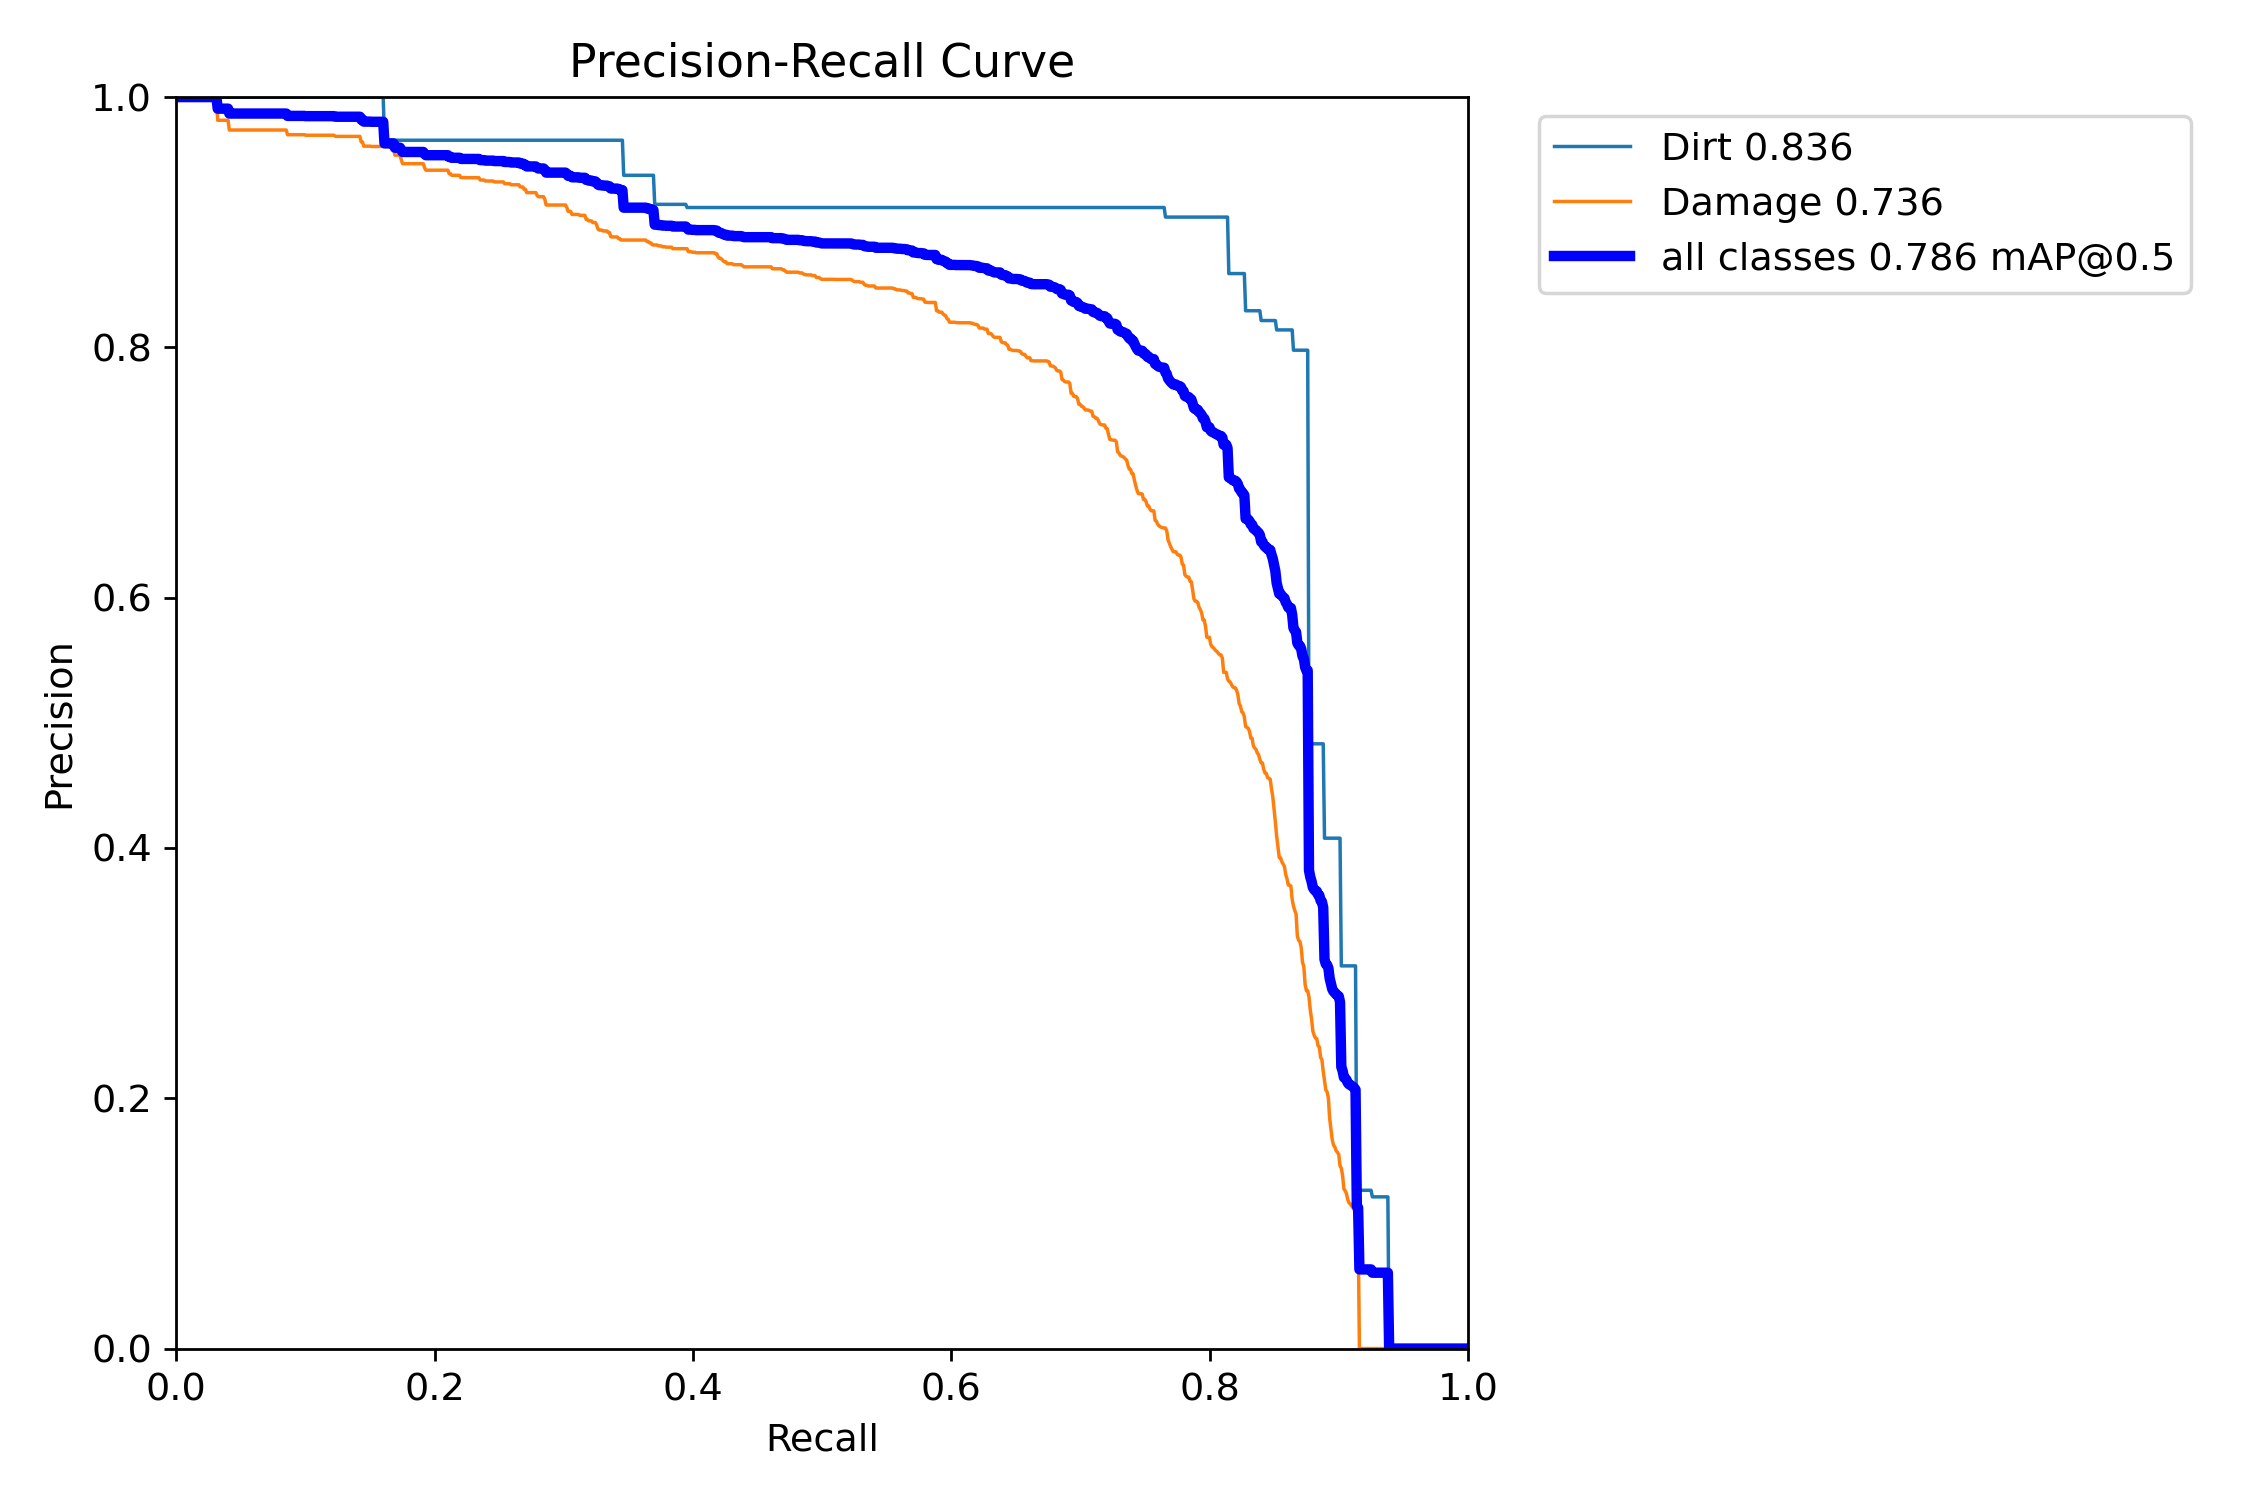

confusion_matrix.png


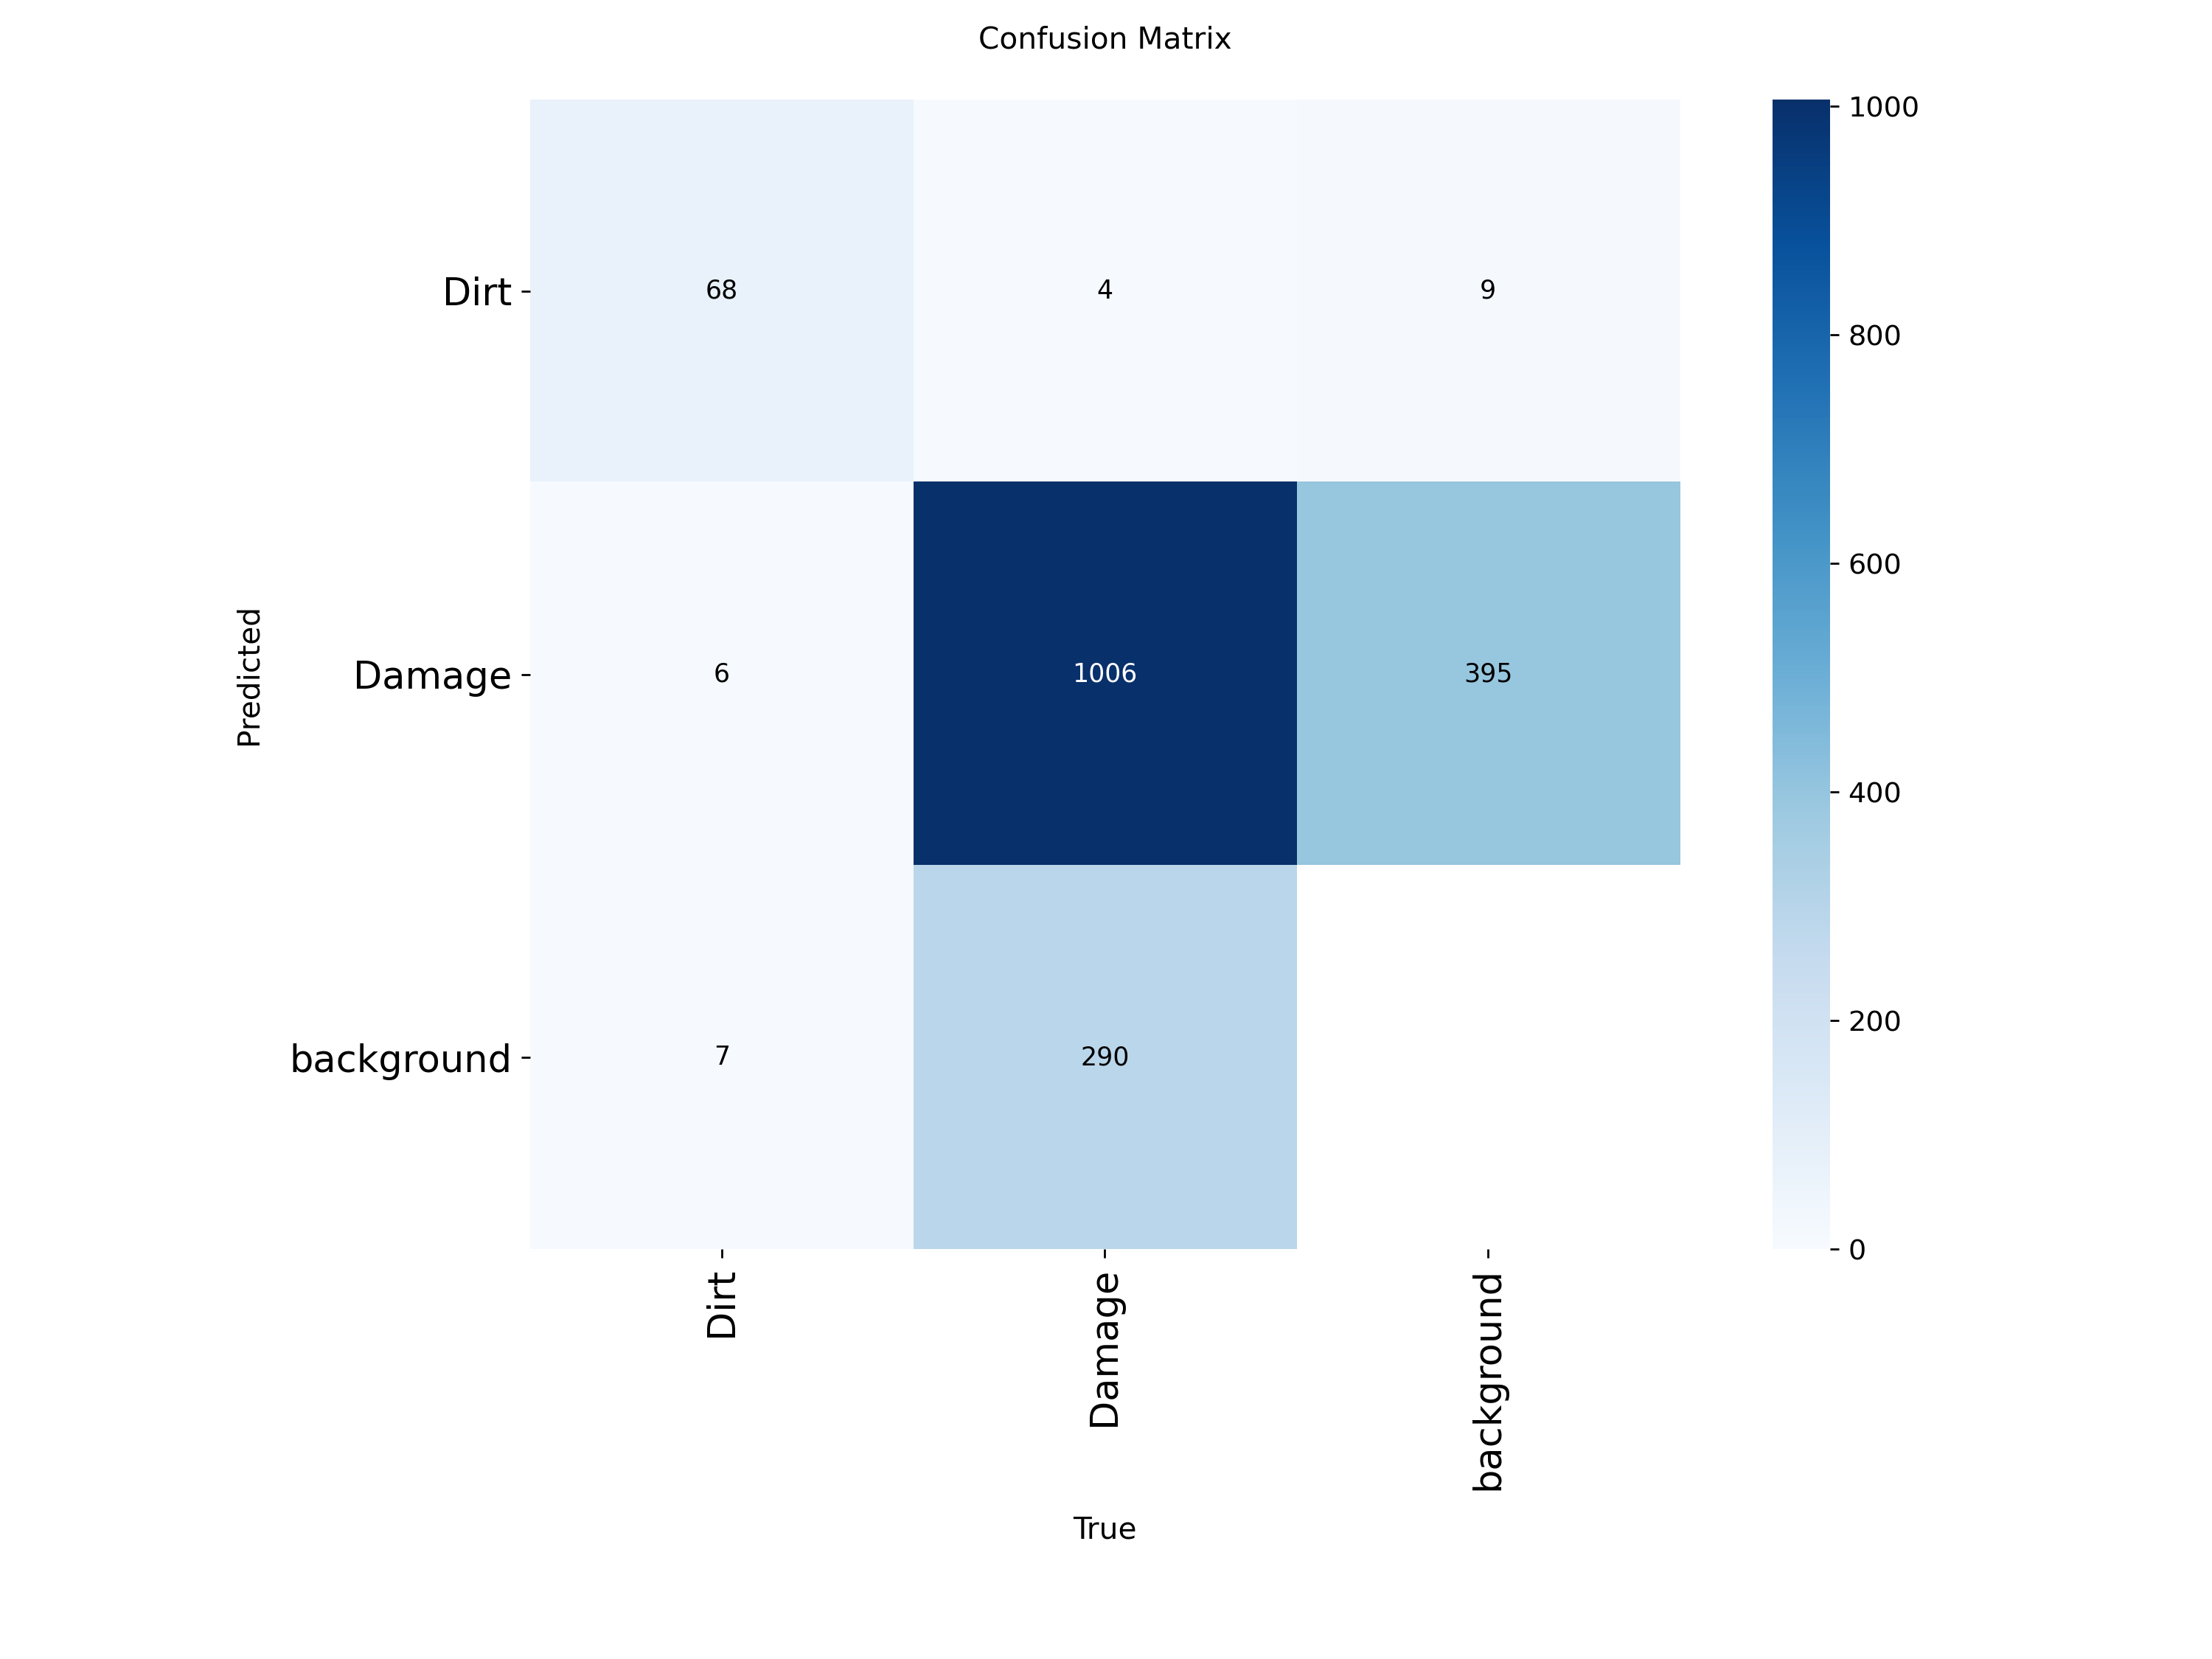

confusion_matrix_normalized.png


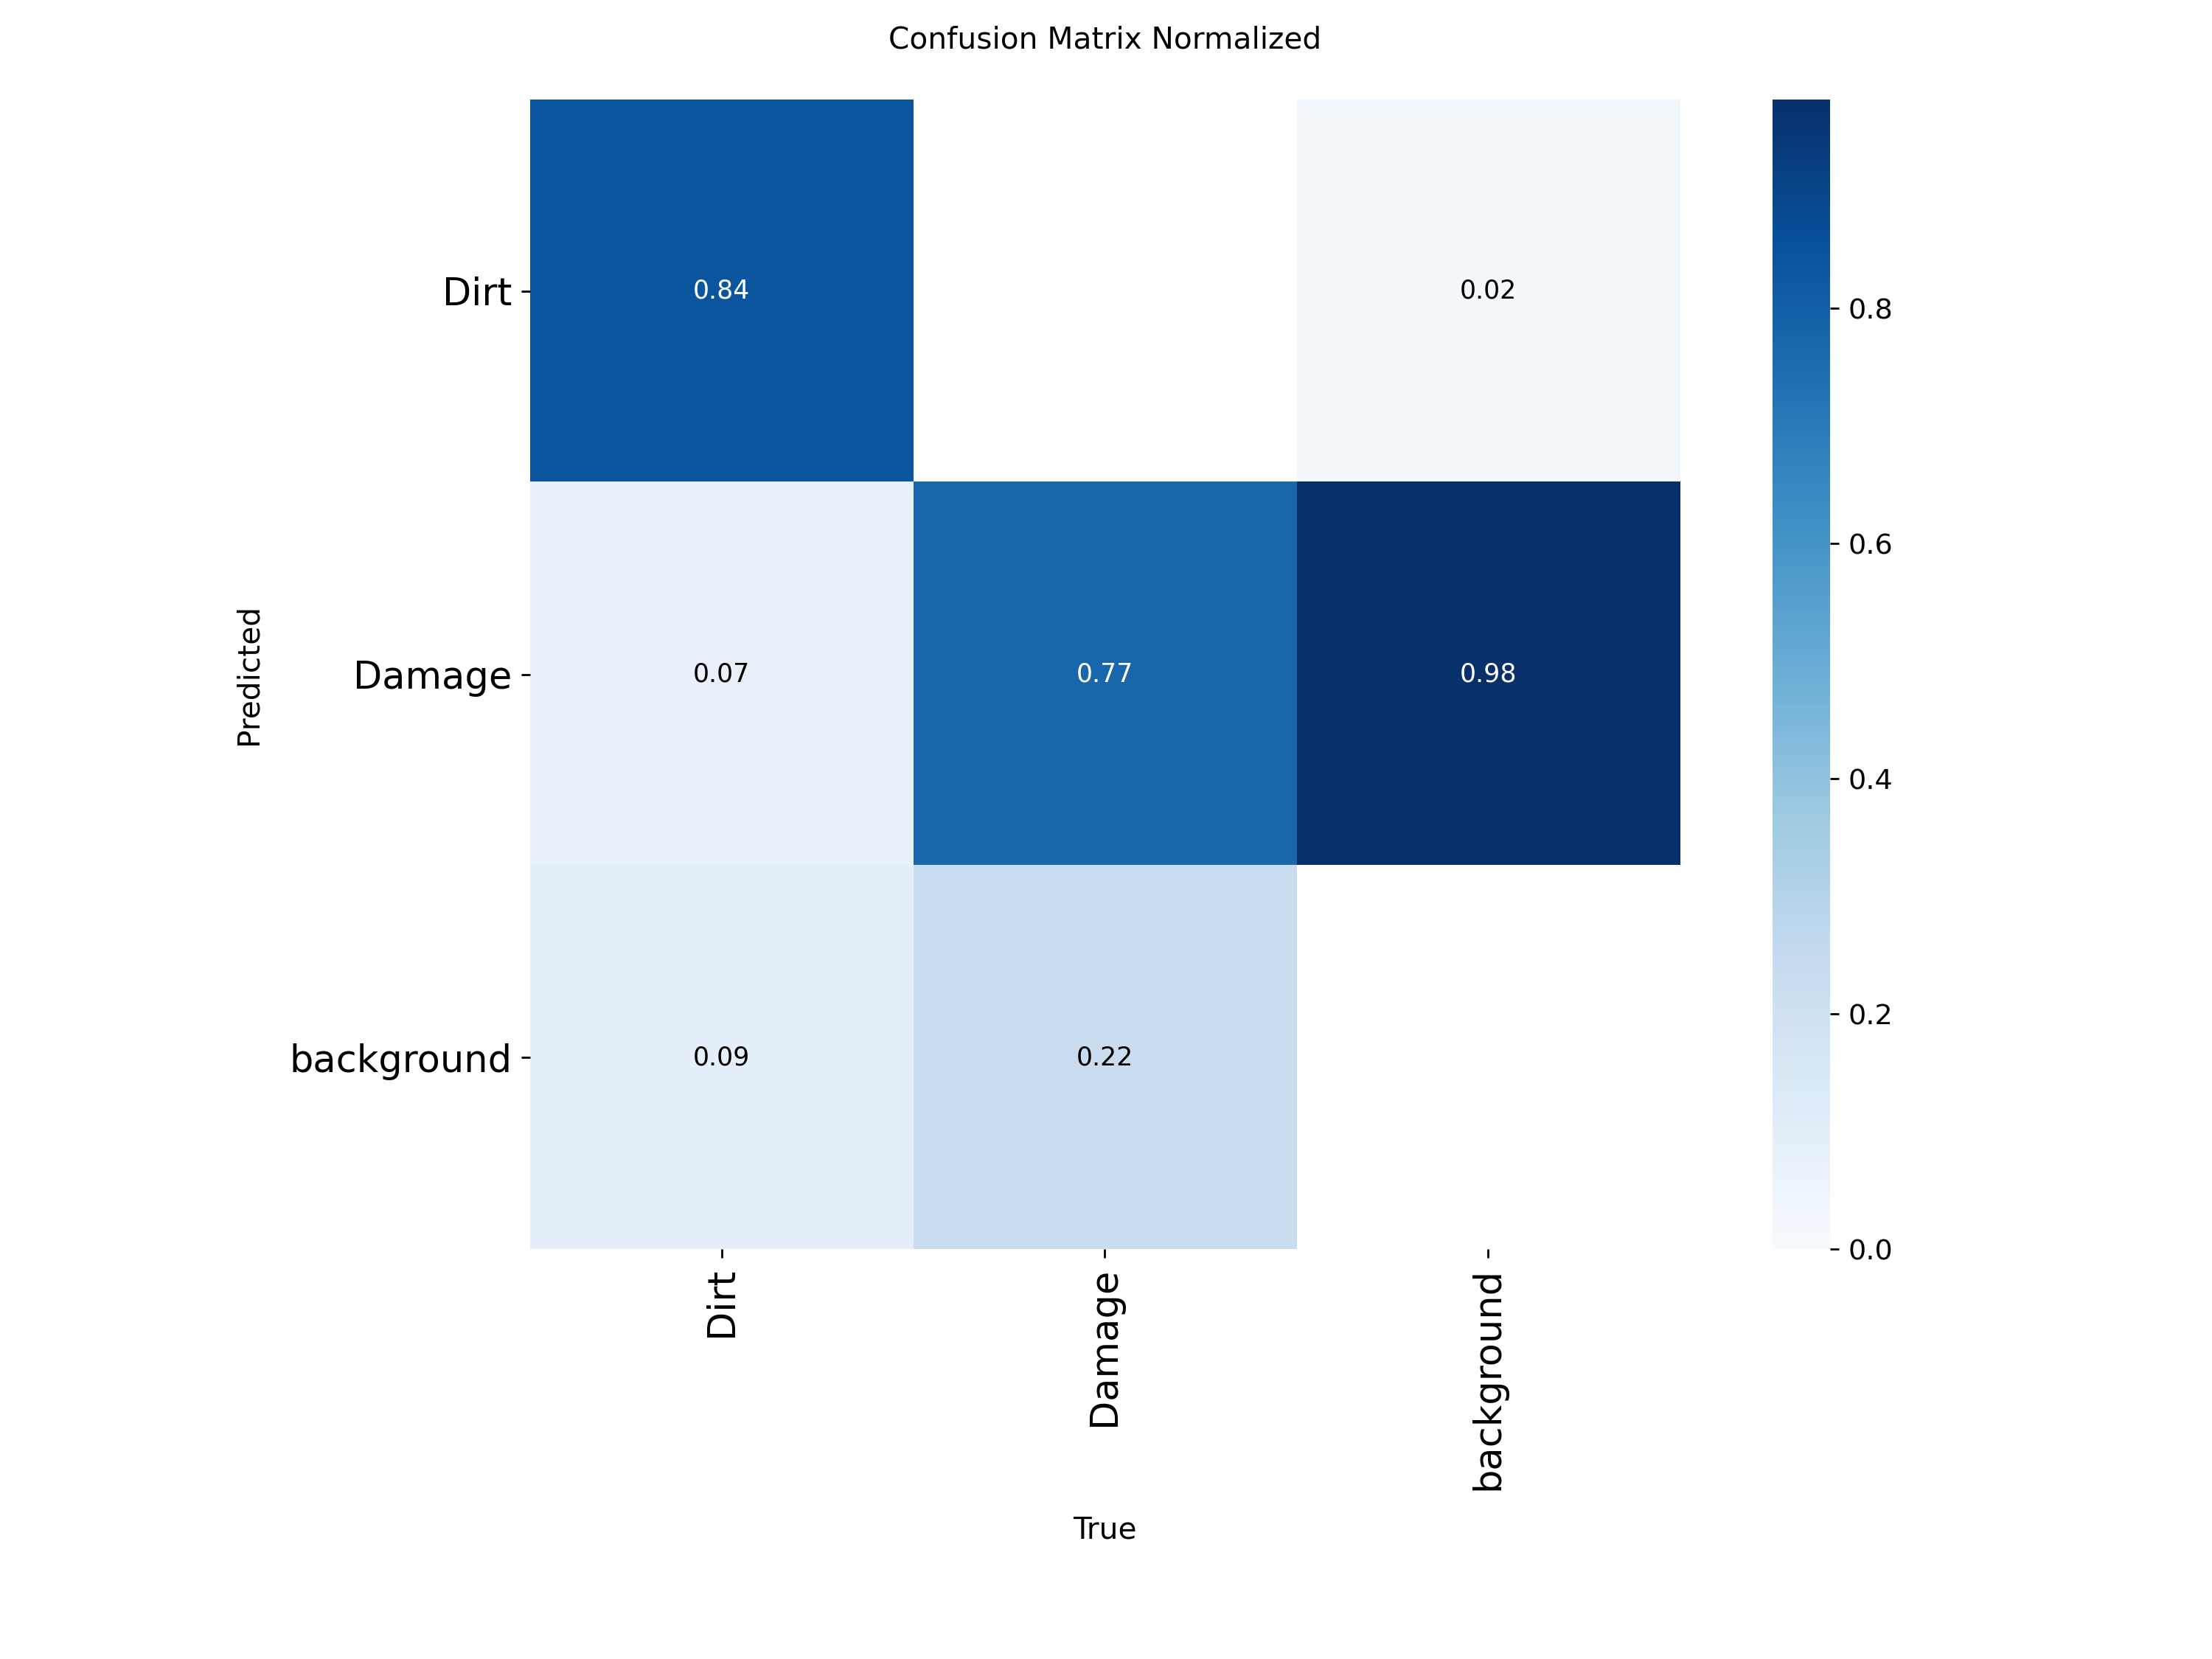

In [ ]:
# test 평가 그림(PR곡선·혼동행렬) 표시
from IPython.display import Image, display
import os
td=os.path.join(RUNS_DIR,'detect',EXP_NAME+'_TEST')
for fn in ['BoxPR_curve.png','confusion_matrix.png','confusion_matrix_normalized.png']:
    p=os.path.join(td,fn)
    if os.path.exists(p): print(fn); display(Image(p))

### 📊 PR 곡선 및 혼동 행렬 분석

#### 1. Precision-Recall (PR) 곡선 분석
* **클래스별 AP 지표 (@0.5):**
  전체 클래스 평균 mAP는 <b>78.6%</b>이며, 클래스별로는 `Dirt(오염)`가 **83.6%**, `Damage(결함)`가 <b>73.6%</b>를 기록하였다.
* **곡선 형태에 따른 특성 (탐지 민감도 이슈):**
  특히 핵심 타겟인 `Damage` 곡선의 경우, 우측 하단으로 갈수록 경사가 급격해지는 형태를 보인다. 이는 결함을 놓치지 않기 위해 모델의 탐지 임계값(Confidence Threshold)을 낮출 경우, 위치 정확도가 떨어지거나 오탐(FP) 노이즈가 발생할 가능성이 높음을 시사한다.

#### 2. 혼동 행렬(Confusion Matrix) 기반 정량 분석
* **예측 신뢰도 우수:**
  모델이 Dirt로 예측한 박스 중 실제 Dirt인 비율(Precision)은 <b>84%</b>, Damage로 예측한 박스 중 실제 Damage인 비율은 <b>77%</b>로 양호한 판별력을 보였다. 즉, 모델이 객체로 판단하여 박스를 생성한 경우, 해당 클래스 분류에 대한 신뢰도는 신뢰할 만한 수준이다.
* **Background 미탐지(FN) 리스크:**
  반면, 모델이 극복해야 할 주요 취약점은 무탐지(Background로 오분류) 비율에서 나타났다. 실제 Dirt 객체의 <b>9%</b>, 그리고 실제 Damage 객체의 <b>22%</b>를 모델이 바운딩 박스를 생성하지 못한 채 정상 배경으로 간주하여 놓치는 현상이 관찰되었다.
* **지표 하락 원인 규명:**
  결과적으로 현재 모델의 mAP 지표를 제약하는 주된 원인은 다른 클래스로 오인하거나 엉뚱한 곳에 박스를 치는 <b>'오탐(False Positive)'</b>이 아니라, 결함을 발견하지 못하고 지나치는 <b>'미탐(False Negative)'</b>에 있음을 통계적으로 증명한다. 이는 앞서 지적한 <b>소형 객체의 해상도 부족으로 인해 모델이 유의미한 특징을 추출하지 못하고 배경으로 흡수해버리는 한계</b>와 일맥상통한다.이러한 미탐 문제를 근본적으로 해결하기 위해서는 Damage 이미지의 양적 확대와 고품질 데이터셋 구축이 수반되어야 한다. 그러나 본 연구의 대상인 풍력 발전기 드론 촬영 이미지의 특성상, 단기간 내에 대량의 특수 데이터를 추가 수집하는 것은 현실적인 제약이 따른다. 따라서 데이터 부족으로 인한 미탐 제어 한계는 본 모델의 한계점으로 명시하며, 향후 고도화 단계에서 해결해야 할 개선 방안으로 제안하고자 한다.
  

#### 3. 차기 정성적 평가(Qualitative Evaluation)의 필요성
* 혼동 행렬 상에서는 오탐률이 10% 미만으로 매우 낮게 집계되지만, 이는 데이터셋 내에 정상 영역(Background)과 배경 이미지의 비율이 압도적으로 높아 발생한 통계적 착시일 가능성이 존재한다.
* 수치적 지표만으로는 모델이 실제로 '정확한 위치에 박스를 치고 있는지' 혹은 '수치에 잡히지 않는 미세한 노이즈성 오탐이 발생하고 있는지' 완벽히 판별할 수 없다.
* 따라서, 본 정량 분석 결과를 검증하기 위해 후속 셀인 **'11. test 추론 시각화' 단계에서 출력되는 실제 이미지들을 육안으로 확인하여 b-box의 탐지 위치와 실제 결함 위치를 대조하는 정성적 평가를 필수적으로 수행**한다.

# 11. test 추론 시각화


0: 416x640 2 Damages, 19.3ms
1: 416x640 12 Damages, 19.3ms
2: 416x640 13 Damages, 19.3ms
3: 416x640 12 Damages, 19.3ms
4: 416x640 7 Damages, 19.3ms
5: 416x640 8 Damages, 19.3ms
Speed: 1.7ms preprocess, 19.3ms inference, 0.9ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/pred/test


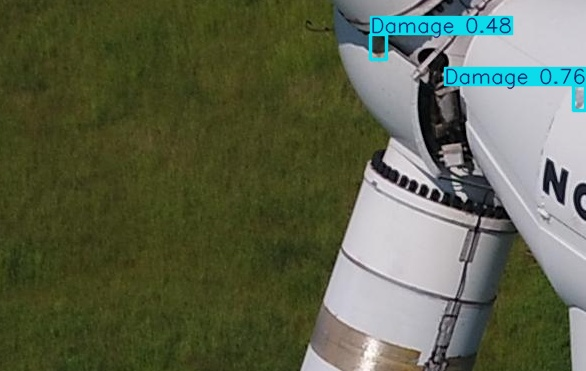

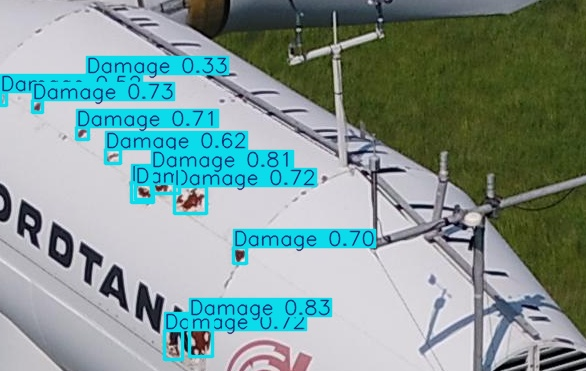

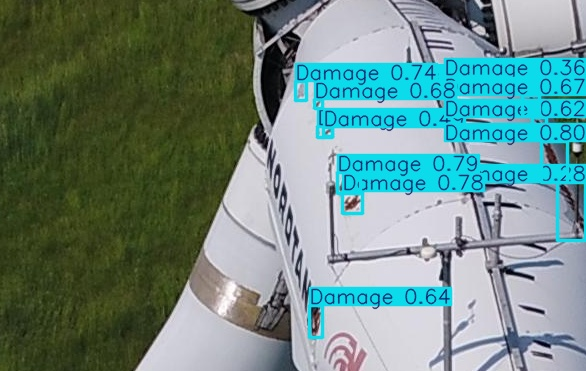

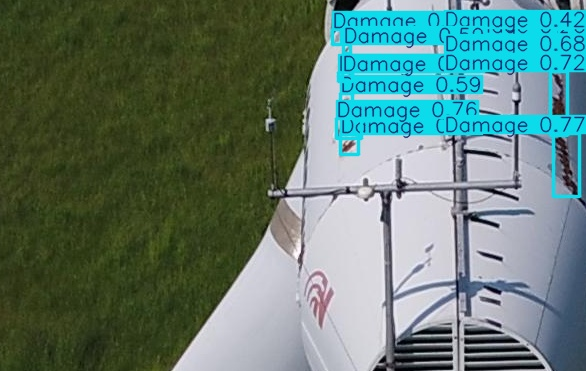

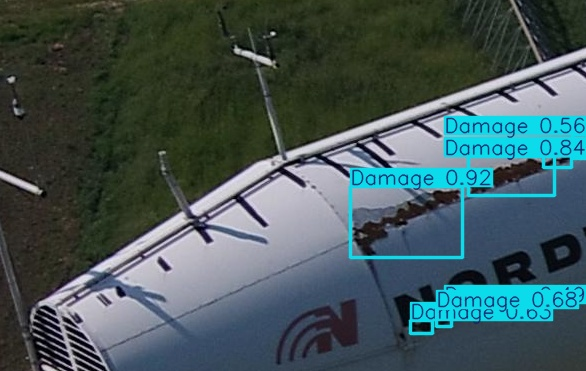

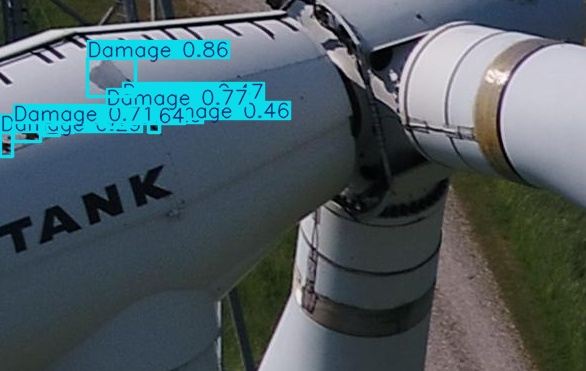

In [ ]:
import glob, os
from ultralytics import YOLO
from IPython.display import Image, display
viz=YOLO(best_pt)
samples=sorted(glob.glob(f'{LOCAL_OUT}/images/test/*'))[:6]
viz.predict(samples, imgsz=IMGSZ, conf=0.25, save=True, project='/content/pred', name='test', exist_ok=True)
for p in sorted(glob.glob('/content/pred/test/*'))[:6]: display(Image(p))


### 👁️ 테스트 데이터 추론 결과 시각화 및 정성적 평가 (Qualitative Evaluation)

#### 1. 정성적 평가의 목적 및 기획
* **수치적 통계의 착시 검증:** 앞선 혼동 행렬(Confusion Matrix) 결과에서는 오탐률(False Positive)이 10% 미만으로 매우 안정적인 수치를 기록하였다. 그러나 이는 데이터셋 내 정상 영역(Background)의 비율이 압도적으로 높아 발생한 통계적 착시일 가능성이 있다.
* **미탐(FN)의 정성적 원인 규명:** 실제 `Damage` 결함의 <b>22%</b>를 모델이 발견하지 못하고 놓치는 '미탐지 리스크'가 확인되었다. 본 시각화 단계에서는 테스트 데이터셋(Test Split)의 추론 이미지를 육안으로 직접 대조하여, 모델이 결함을 놓친 실제 환경적 요인(미세한 크기, 광량, 터빈 표면의 음영 등)을 정성적으로 분석한다.

#### 2. 주요 정성적 검증 포인트
1. **위치 정확도(Localization) 평가:** 모델이 생성한 바운딩 박스(b-box)가 실제 결함의 경계를 어느 정도 수준으로 포착하고 있는지 확인한다.
2. **신뢰도 점수(Confidence Score) 분석:** 탐지된 객체 위에 표기된 확률값(예: `Damage 0.76`)을 통해 모델이 결함과 단순 오염(`Dirt`)을 얼마나 확신하여 분별하고 있는지 판단한다.
3. **노이즈성 오탐 탐색:** 수치 지표에는 크게 잡히지 않았으나, 실제 사진 상에서 블레이드의 가장자리나 음영진 스크래치 등을 결함으로 잘못 짚는 미세한 노이즈가 존재하는지 추적한다.

#### 3. 시각화 결과 분석 및 제품화 관점의 해석
* **제품화 방향성과 탐지 의의:** 본 프로젝트가 지향하는 제품화 방향성은 풍력 발전기 표면의 손상이나 오염 발생 여부를 상시 모니터링하고, 결함이 누적 탐지될 경우 사용자에게 경고 알림을 제공하는 **'스마트 예방 정비 시스템'** 구축이다.
* **정성적 평가 결론:** 이러한 서비스 목적을 고려할 때, 픽셀 단위의 극단적인 위치 정확도(Localization)를 달성하는 것보다 <b>'결함이 존재하는 영역에 놓치지 않고 바운딩 박스를 생성해내는 것 자체'</b>가 비즈니스적으로 훨씬 중요한 평가지표이다. 실제 시각화 결과를 육안으로 검증한 결과, 주요 `Damage` 발생 구역에 누락 없이 알맞은 b-box가 배치되어 있음을 확인하였으며, 이는 실제 현장에 도입하기에 충분히 만족할 만한 실용적 성능을 갖추었음을 시사한다.

# NOTE

---

```
이번 프로젝트는 제주도 런케이션에 맞춰서 풍력 발전기의 표면 이미지 데이터셋을 이용하여 Object Detection 모델을 학습하고 평가하여 최종적으로 제품화로 발전시키는 것이었다. 
처음에는 YOLO뒤에 붙는 소문자가 무슨 뜻인지도 모르고, 타일링이 뭔지, SAHI가 뭔지도 모르면서 일단 캐글에 있는 코드를 따라 쳤다. 팀원들과 함께 맨땅에 해딩하며 수십번의 시행착오를 거쳤고, 우리가 가진 데이터의 한계성을 인식하고 모델을 정량적으로 평가해야 하지만 정성적으로도 평가해야 한다는 것을 몸소 깨달을 수 있는 기회였다.  
그리고 양질의 데이터가 얼마나 중요한지, 대량의 데이터를 모으는 것이 얼마나 중요한지도 피부를 느끼게 되었다. 손상과 오염 이미지가 조금만 더 많았다면 더 좋은 모델을 만들 수 있었을거라는 아쉬움이 계속 남는다. 
```